<a href="https://colab.research.google.com/github/ThiagoMHora/AgentesInteligentes_Semana4_Practica/blob/main/AlgoritmoLaberinto_Semana04_Practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PARTE 1: GENERACIÓN ESTRUCTURADA CON RIESGO DE BLOQUEO ---
Filas aproximadas (ej. 41): 15
Columnas aproximadas (ej. 41): 15


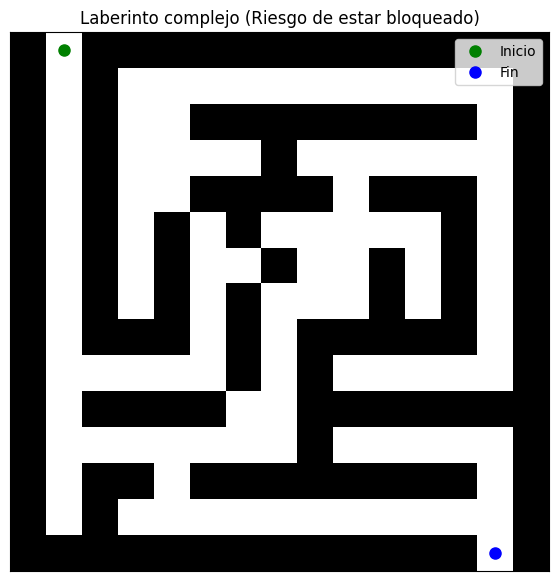

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# =============================================================================
# PARTE 1: CREACIÓN DEL LABERINTO (COMPLEJO + POSIBILIDAD DE NO SOLUCIÓN)
# =============================================================================
def generar_laberinto_con_derrumbes(filas, columnas, prob_derrumbe=0.04):
    # Ajuste a números impares
    filas = filas if filas % 2 != 0 else filas + 1
    columnas = columnas if columnas % 2 != 0 else columnas + 1

    laberinto = np.ones((filas, columnas), dtype=int)
    inicio_excavacion = (1, 1)
    laberinto[inicio_excavacion] = 0
    pila = [inicio_excavacion]

    # PASO 1: Algoritmo de Excavación (Crea la estructura de pasillos limpios)
    while pila:
        r, c = pila[-1]
        direcciones = [(0, 2), (0, -2), (2, 0), (-2, 0)]
        random.shuffle(direcciones)

        excavado = False
        for dr, dc in direcciones:
            nr, nc = r + dr, c + dc
            if 0 < nr < filas-1 and 0 < nc < columnas-1 and laberinto[nr, nc] == 1:
                laberinto[r + dr//2, c + dc//2] = 0
                laberinto[nr, nc] = 0
                pila.append((nr, nc))
                excavado = True
                break

        if not excavado:
            pila.pop()

    # PASO 2: Complejidad (Atajos en el centro del mapa)
    paredes_a_romper = (filas * columnas) // 25
    rotas = 0
    radio_seguridad = filas // 4

    while rotas < paredes_a_romper:
        r, c = random.randint(1, filas-2), random.randint(1, columnas-2)
        distancia_inicio = abs(r - 0) + abs(c - 1)
        distancia_fin = abs(r - (filas-1)) + abs(c - (columnas-2))

        if distancia_inicio > radio_seguridad and distancia_fin > radio_seguridad:
            if laberinto[r, c] == 1:
                laberinto[r, c] = 0
                rotas += 1

    # PASO 3: DERRUMBES (El factor que puede volverlo sin solución)
    # Buscamos todas las coordenadas que actualmente son camino (0)
    caminos_existentes = np.argwhere(laberinto == 0)
    # Calculamos cuántos pasillos vamos a tapar (ej. el 4% de ellos)
    cantidad_derrumbes = int(len(caminos_existentes) * prob_derrumbe)

    for _ in range(cantidad_derrumbes):
        idx = random.randint(0, len(caminos_existentes) - 1)
        r, c = caminos_existentes[idx]
        # Protegemos estrictamente la casilla de inicio y fin para que no caiga ahí
        if (r, c) != (0, 1) and (r, c) != (filas-1, columnas-2):
            laberinto[r, c] = 1 # Convertimos el pasillo en pared

    # Entradas y salidas oficiales
    laberinto[0, 1] = 0
    laberinto[filas-1, columnas-2] = 0

    return laberinto, filas, columnas

def dibujar(laberinto, camino=None, titulo="", color_ruta='red'):
    plt.figure(figsize=(7, 7))
    plt.imshow(laberinto, cmap='binary')
    if camino:
        camino_y = [p[0] for p in camino]
        camino_x = [p[1] for p in camino]
        plt.plot(camino_x, camino_y, color=color_ruta, linewidth=2.5)

    plt.plot(1, 0, 'go', markersize=8, label='Inicio')
    plt.plot(laberinto.shape[1]-2, laberinto.shape[0]-1, 'bo', markersize=8, label='Fin')
    plt.title(titulo)
    plt.legend(loc='upper right')
    plt.xticks([]); plt.yticks([])
    plt.show()

print("--- PARTE 1: GENERACIÓN ESTRUCTURADA CON RIESGO DE BLOQUEO ---")
try:
    f = int(input("Filas aproximadas (ej. 41): "))
    c = int(input("Columnas aproximadas (ej. 41): "))

    # prob_derrumbe=0.04 significa que taparemos el 4% de los pasillos.
    # Puedes subir este número a 0.08 o 0.10 si quieres que casi nunca tenga solución.
    mi_laberinto, FILAS, COLUMNAS = generar_laberinto_con_derrumbes(f, c, prob_derrumbe=0.04)
    dibujar(mi_laberinto, titulo="Laberinto complejo (Riesgo de estar bloqueado)")
except ValueError:
    print("Ingresa números válidos.")
    mi_laberinto = None

--- PARTE 2: SOLUCIÓN DETERMINÍSTICA (BFS) ---
Lógica Matemática -> Casillas analizadas: 55 | Longitud de ruta: 27


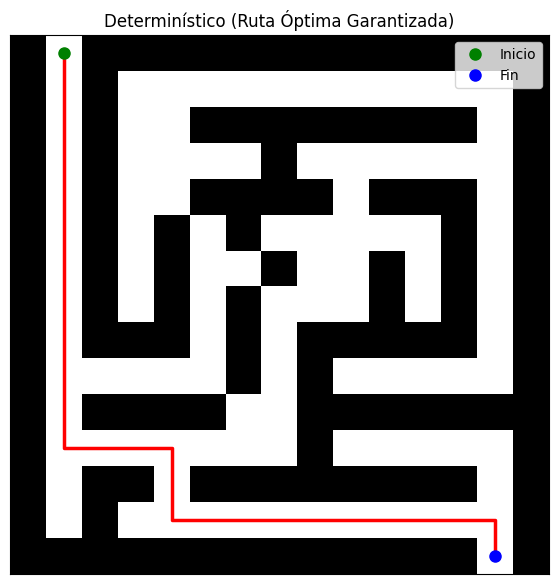

In [22]:
# =============================================================================
# PARTE 2: SOLUCIÓN DETERMINÍSTICA (BÚSQUEDA EN ANCHURA - BFS)
# =============================================================================
def resolver_deterministico(laberinto):
    inicio = (0, 1)
    fin = (FILAS - 1, COLUMNAS - 2)

    cola = deque([(inicio, [inicio])])
    visitados = set([inicio])
    intentos = 0
    movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while cola:
        (r, c), camino = cola.popleft()
        intentos += 1

        if (r, c) == fin:
            return True, camino, intentos

        for dr, dc in movimientos:
            nr, nc = r + dr, c + dc
            if 0 <= nr < FILAS and 0 <= nc < COLUMNAS:
                if laberinto[nr, nc] == 0 and (nr, nc) not in visitados:
                    visitados.add((nr, nc))
                    cola.append(((nr, nc), camino + [(nr, nc)]))

    return False, [], intentos

if mi_laberinto is not None:
    print("--- PARTE 2: SOLUCIÓN DETERMINÍSTICA (BFS) ---")
    exito_det, ruta_det, int_det = resolver_deterministico(mi_laberinto)
    print(f"Lógica Matemática -> Casillas analizadas: {int_det} | Longitud de ruta: {len(ruta_det)}")
    dibujar(mi_laberinto, ruta_det, titulo="Determinístico (Ruta Óptima Garantizada)", color_ruta='red')
else:
    print("Primero debes ejecutar la CELDA 1 para crear un laberinto.")

--- PARTE 3: SOLUCIÓN NO DETERMINÍSTICA INFORMADA ---
Heurística + Azar -> Casillas analizadas: 95 | Longitud de ruta: 27


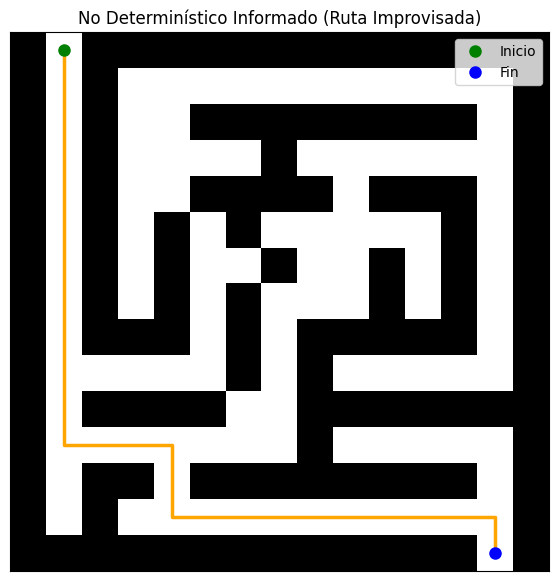

In [23]:
# =============================================================================
# PARTE 3: SOLUCIÓN NO DETERMINÍSTICA INFORMADA (DFS ESTOCÁSTICO)
# =============================================================================
def resolver_no_deterministico_informado(laberinto):
    inicio = (0, 1)
    fin = (FILAS - 1, COLUMNAS - 2)

    pila = [(inicio, [inicio])]
    visitados = set([inicio])
    intentos = 0

    def distancia_meta(r, c):
        return abs(r - fin[0]) + abs(c - fin[1])

    while pila:
        (r, c), camino = pila.pop()
        intentos += 1

        if (r, c) == fin:
            return True, camino, intentos

        vecinos_validos = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < FILAS and 0 <= nc < COLUMNAS:
                if laberinto[nr, nc] == 0 and (nr, nc) not in visitados:
                    vecinos_validos.append((nr, nc))
                    visitados.add((nr, nc))

        # El ruido aleatorio altera la prioridad perfecta de la heurística
        vecinos_validos.sort(key=lambda pos: distancia_meta(pos[0], pos[1]) + random.uniform(-5, 5), reverse=True)

        for vecino in vecinos_validos:
            pila.append((vecino, camino + [vecino]))

    return False, [], intentos

if mi_laberinto is not None:
    print("--- PARTE 3: SOLUCIÓN NO DETERMINÍSTICA INFORMADA ---")
    exito_no_det, ruta_no_det, int_no_det = resolver_no_deterministico_informado(mi_laberinto)
    print(f"Heurística + Azar -> Casillas analizadas: {int_no_det} | Longitud de ruta: {len(ruta_no_det)}")
    dibujar(mi_laberinto, ruta_no_det, titulo="No Determinístico Informado (Ruta Improvisada)", color_ruta='orange')
else:
    print("Primero debes ejecutar la CELDA 1 para crear un laberinto.")